[Cycle Split] Looking for cycles: start ~100±20, end ~200000±10000
[Cycle Split] First 10 frequencies: [ 100.  601. 1102. 1603. 2104. 2605. 3106. 3607. 4108. 4609.]
[Cycle Split] Found 10 cycles (first point removed from each complete cycle)

Processing cycle 1 (points 1-381)

Analyzing cycle 1


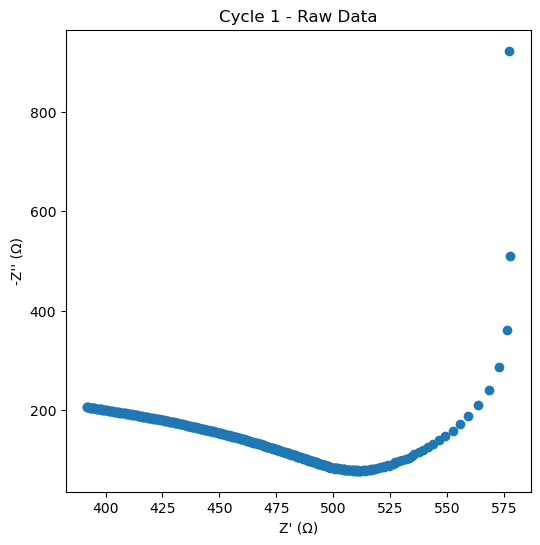

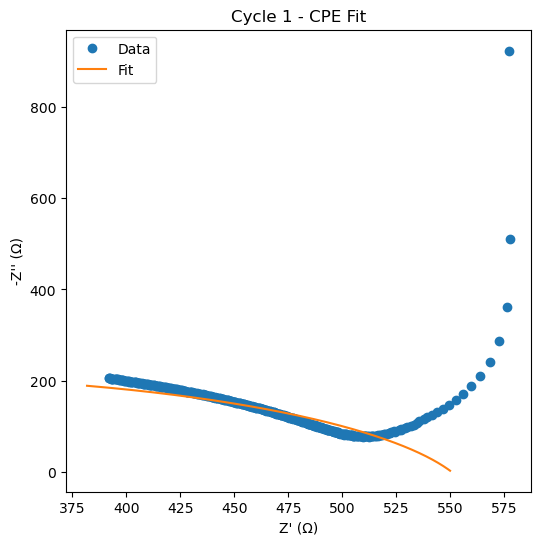


Processing cycle 2 (points 401-781)

Analyzing cycle 2


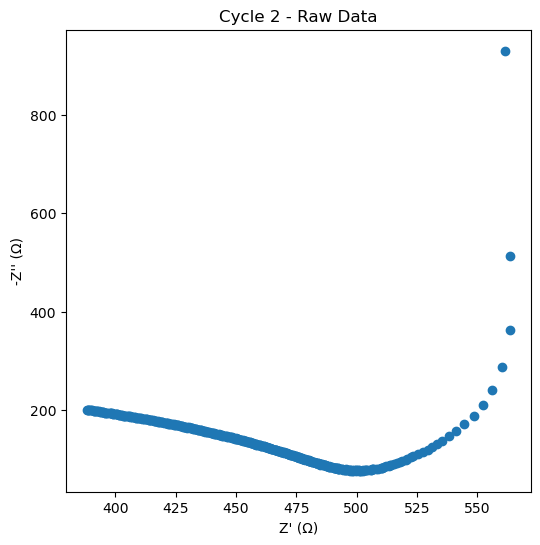

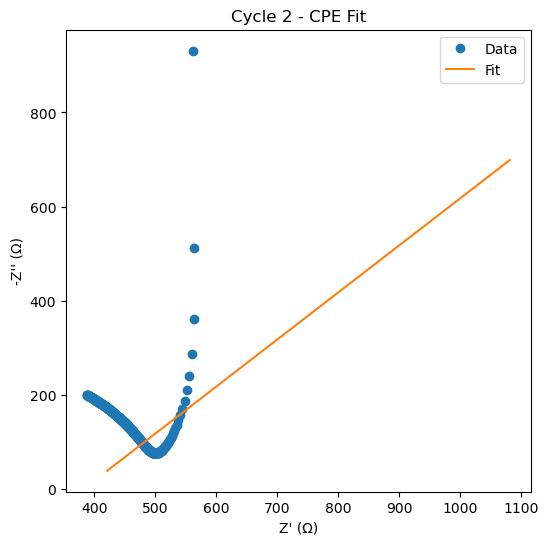


Processing cycle 3 (points 801-1181)

Analyzing cycle 3


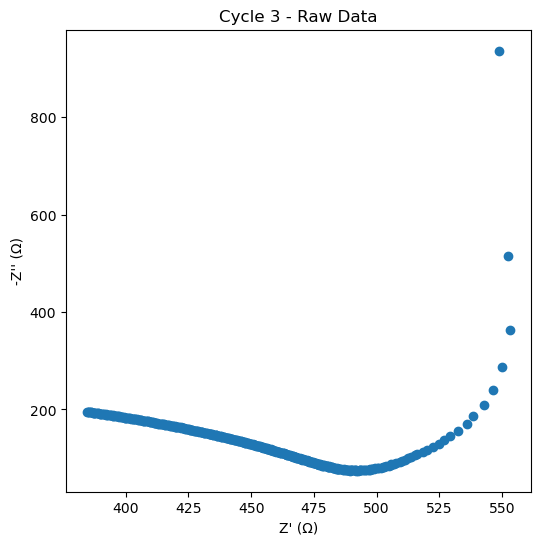

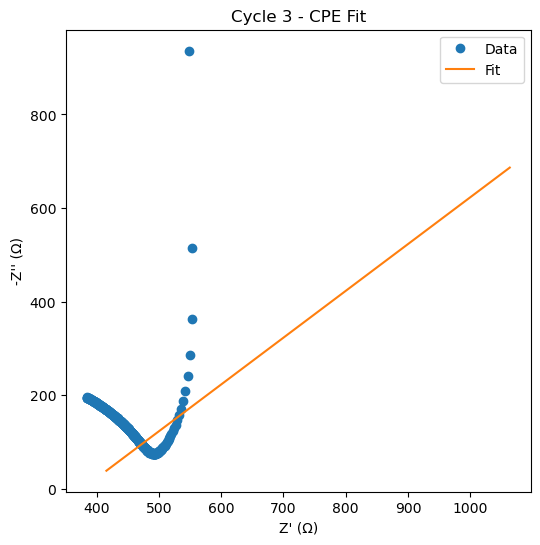


Processing cycle 4 (points 1201-1581)

Analyzing cycle 4


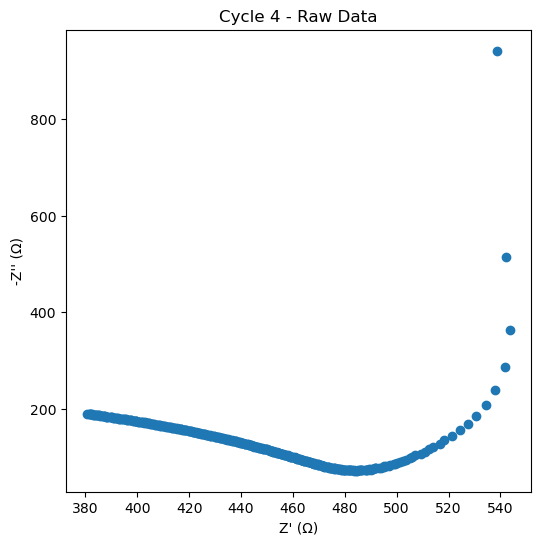

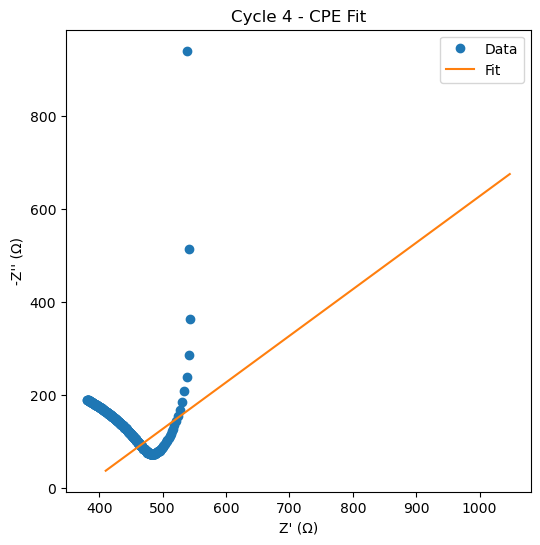


Processing cycle 5 (points 1601-1981)

Analyzing cycle 5


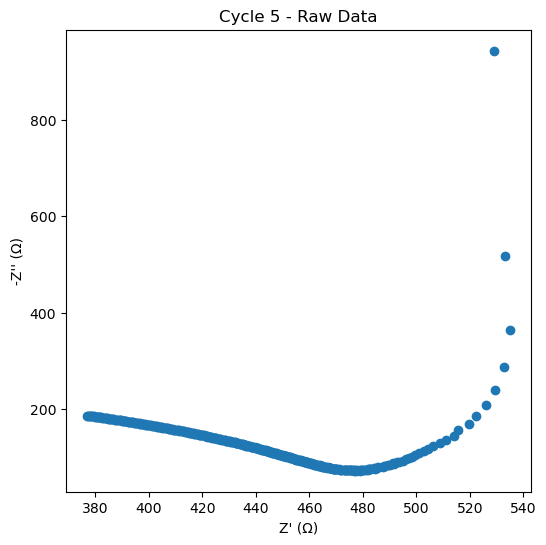

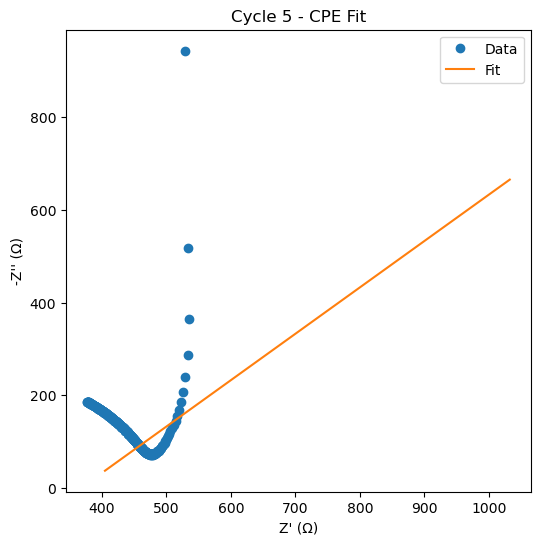


Processing cycle 6 (points 2001-2381)

Analyzing cycle 6


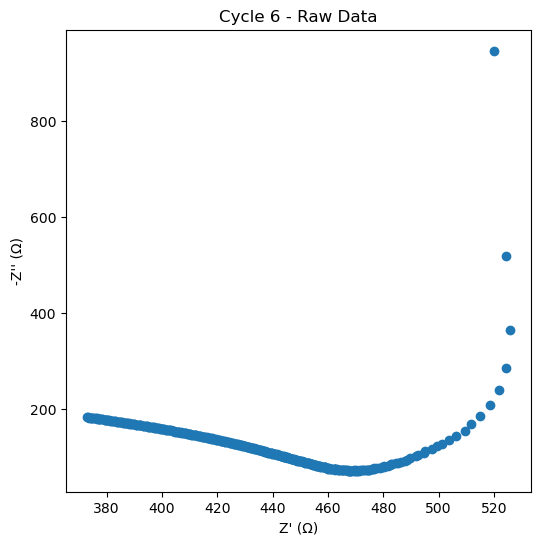

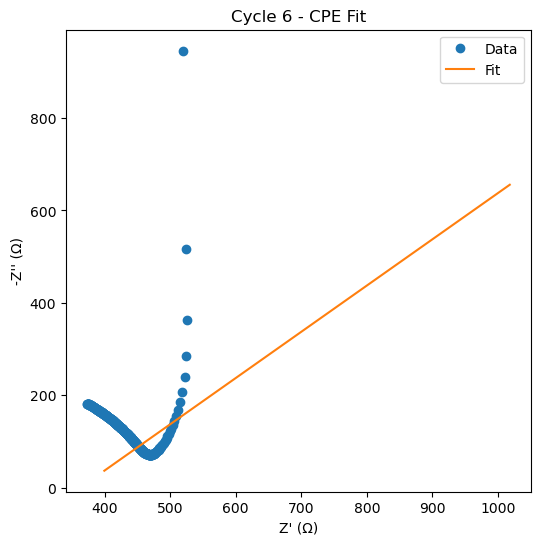


Processing cycle 7 (points 2401-2781)

Analyzing cycle 7


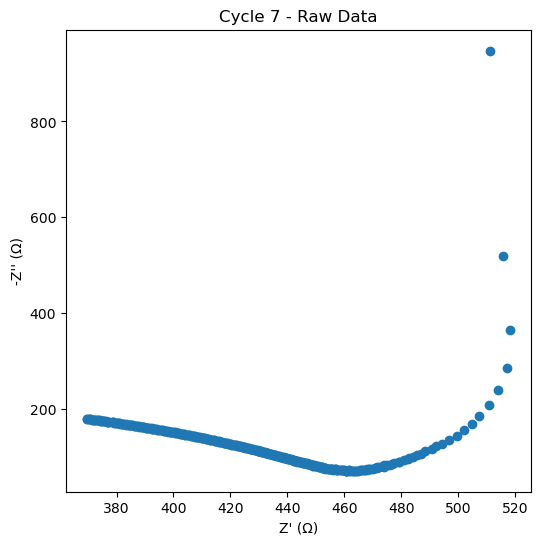

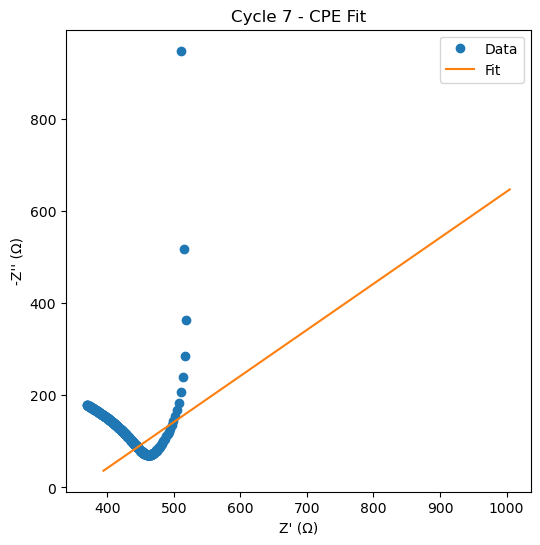


Processing cycle 8 (points 2801-3181)

Analyzing cycle 8


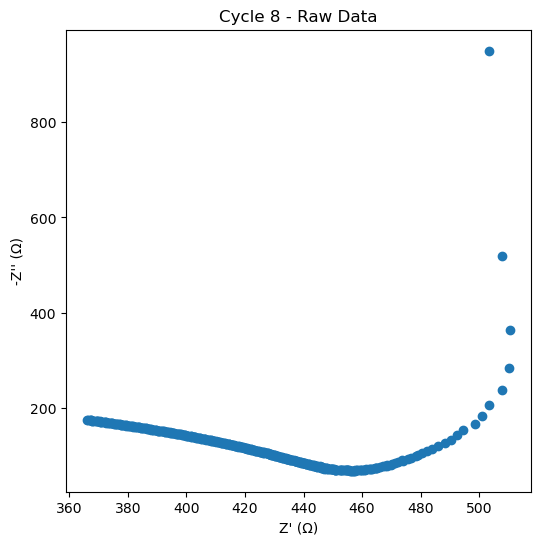

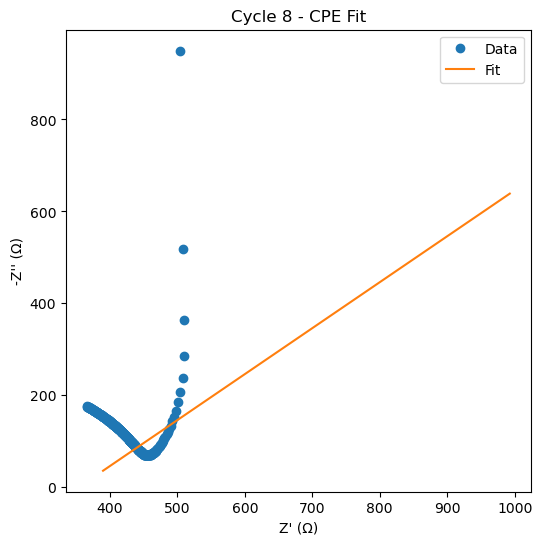


Processing cycle 9 (points 3201-3581)

Analyzing cycle 9


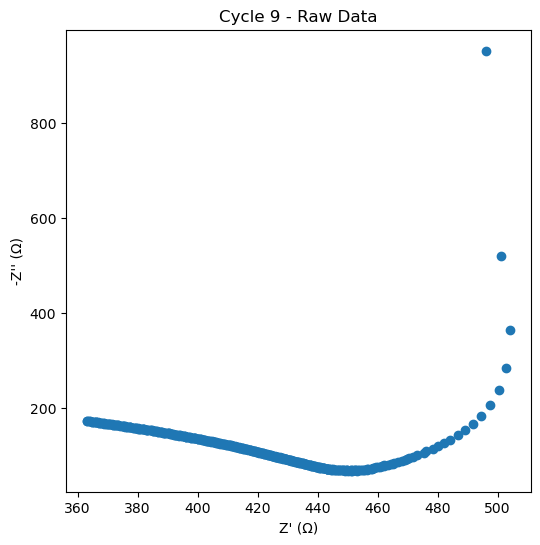

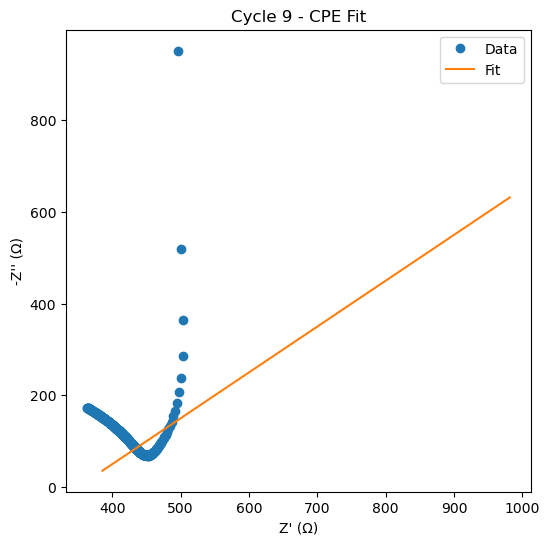


Processing cycle 10 (points 3601-3981)

Analyzing cycle 10


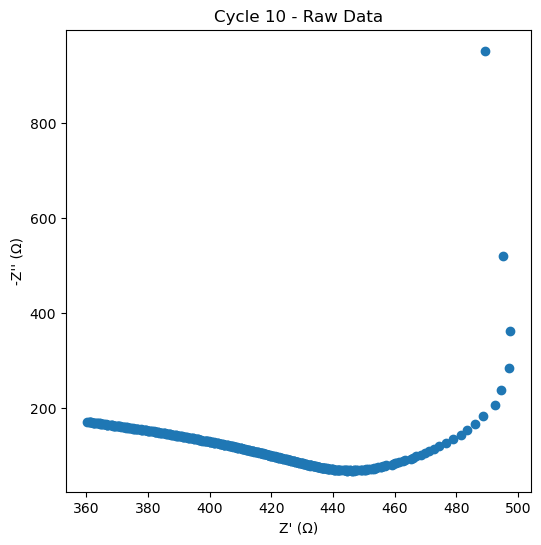

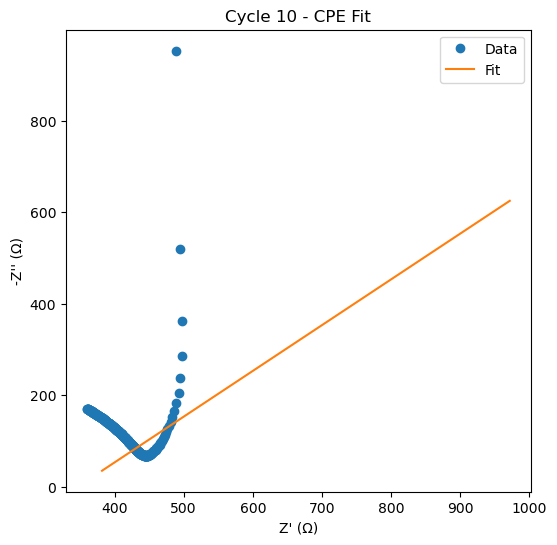


Summary of all cycles:

Cycle 1 (CPE model):
=== Modeled Parameters (CPE) ===
ΔRₑ (Solution Resistance):
  Experimental = 391.87 Ω
  Modeled (R0) = 0.00 Ω

ΔRₑₜ (Charge Transfer Resistance):
  Experimental ≈ 185.46 Ω
  Modeled (Rp) = 550.64 Ω

CPE Parameters:
  Q = 1.001e-08 S·s^n (pseudo-capacitance)
  n = 0.83 (0=resistor, 1=capacitor)

Quality Checks:
  ΔRₑ difference: 391.87 Ω
  ΔRₑₜ difference: 196.9%

----------------------------------

Cycle 2 (CPE model):
=== Modeled Parameters (CPE) ===
ΔRₑ (Solution Resistance):
  Experimental = 388.35 Ω
  Modeled (R0) = 382.19 Ω

ΔRₑₜ (Charge Transfer Resistance):
  Experimental ≈ 173.09 Ω
  Modeled (Rp) = 146180077.43 Ω

CPE Parameters:
  Q = 1.646e-05 S·s^n (pseudo-capacitance)
  n = 0.50 (0=resistor, 1=capacitor)

Quality Checks:
  ΔRₑ difference: 6.17 Ω
  ΔRₑₜ difference: 84453119.4%

----------------------------------

Cycle 3 (CPE model):
=== Modeled Parameters (CPE) ===
ΔRₑ (Solution Resistance):
  Experimental = 384.57 Ω
  Modeled (

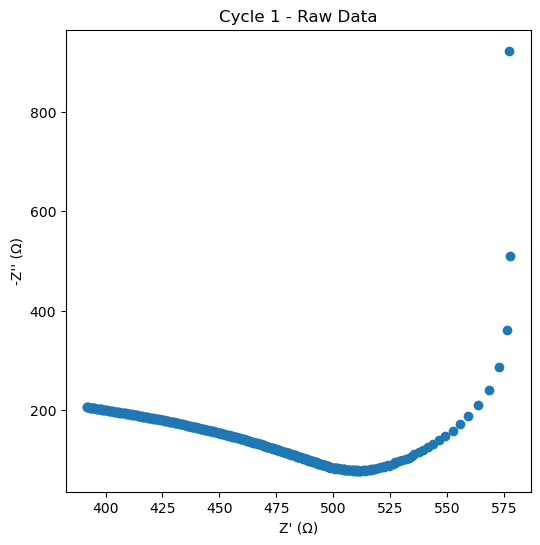

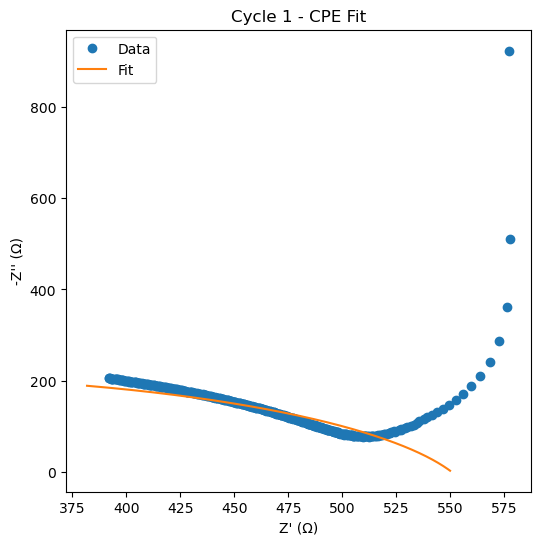


Processing cycle 2 (points 401-781)

Analyzing cycle 2


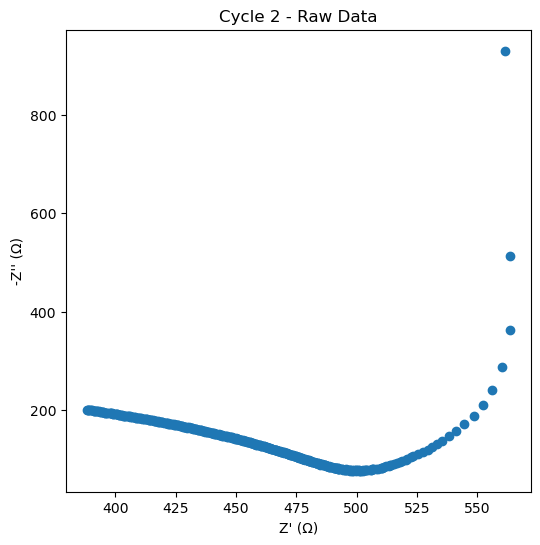

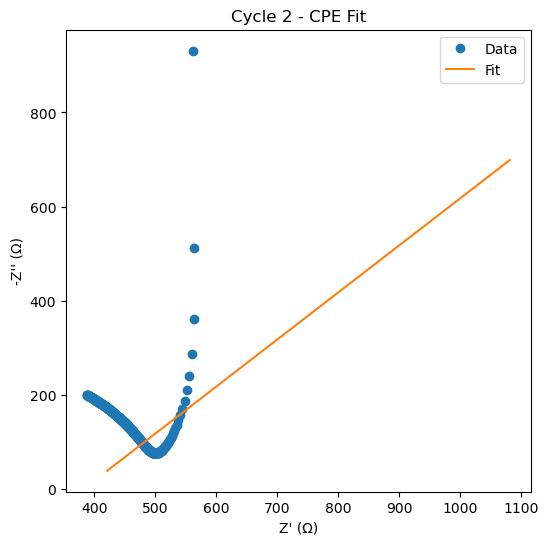


Processing cycle 3 (points 801-1181)

Analyzing cycle 3


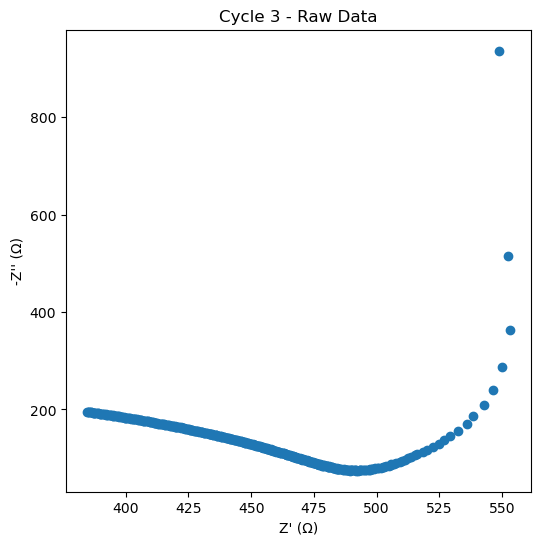

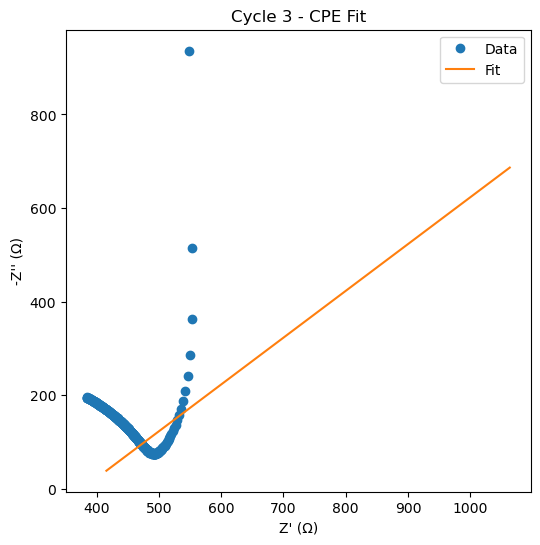


Processing cycle 4 (points 1201-1581)

Analyzing cycle 4


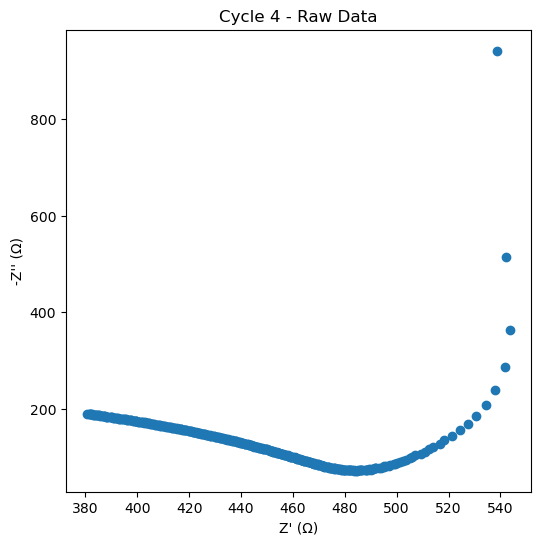

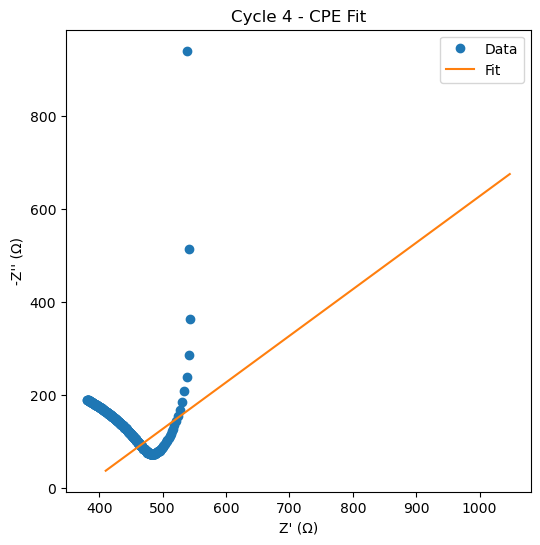


Processing cycle 5 (points 1601-1981)

Analyzing cycle 5


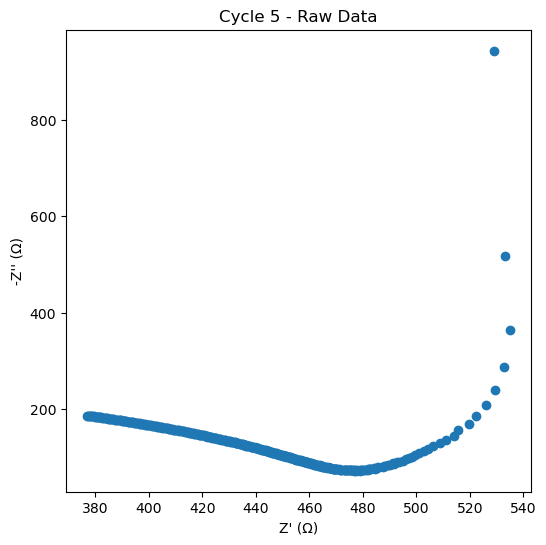

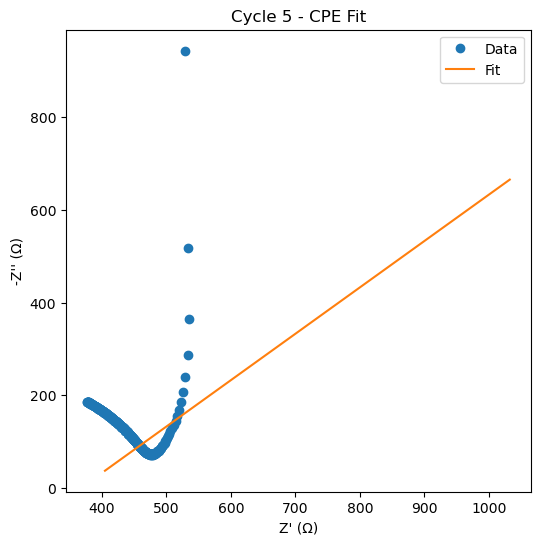


Processing cycle 6 (points 2001-2381)

Analyzing cycle 6


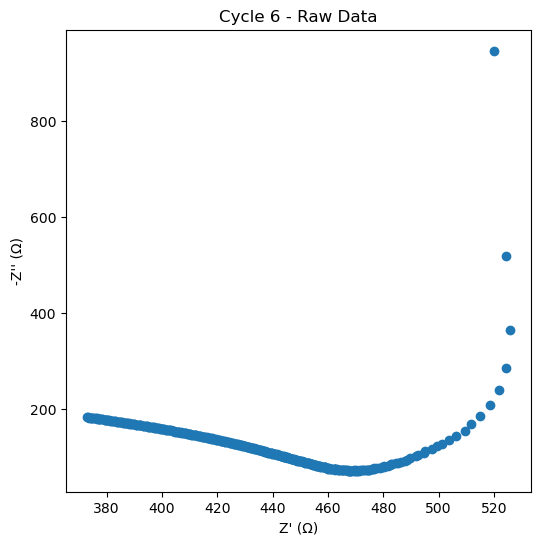

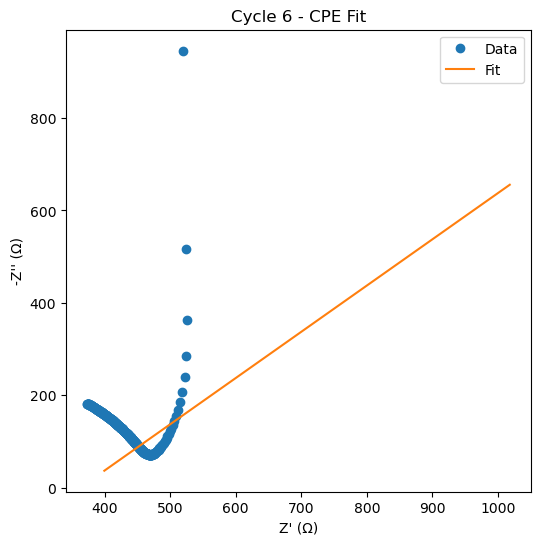


Processing cycle 7 (points 2401-2781)

Analyzing cycle 7


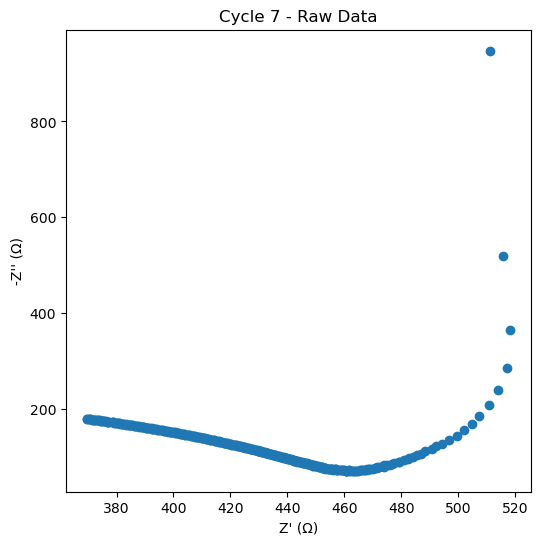

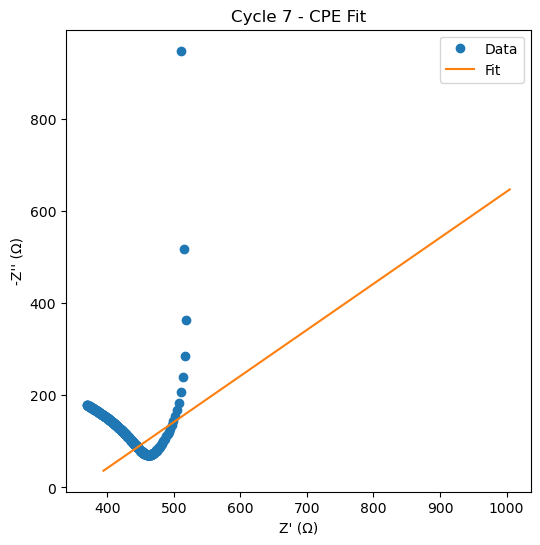


Processing cycle 8 (points 2801-3181)

Analyzing cycle 8


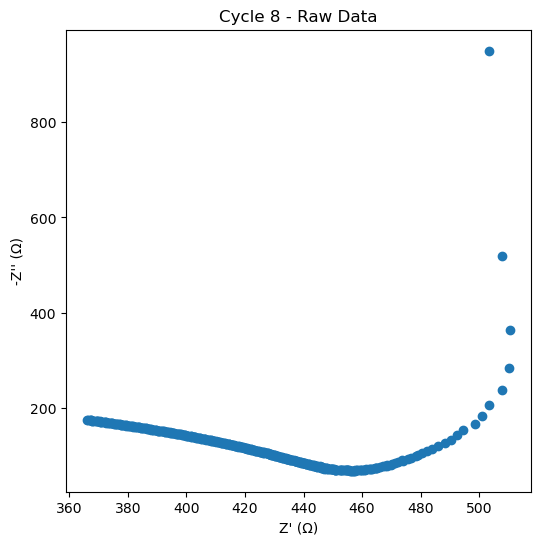

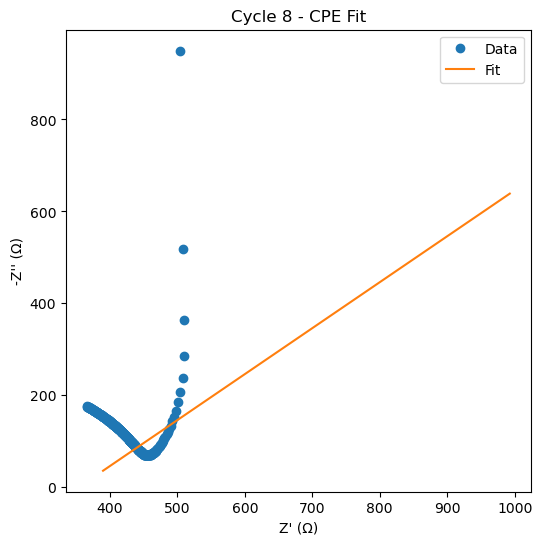


Processing cycle 9 (points 3201-3581)

Analyzing cycle 9


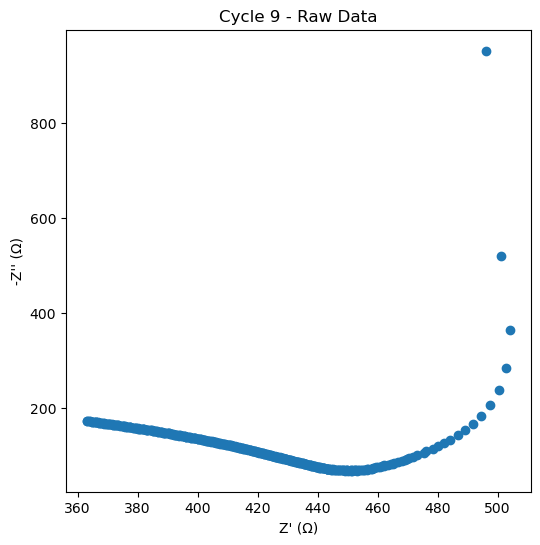

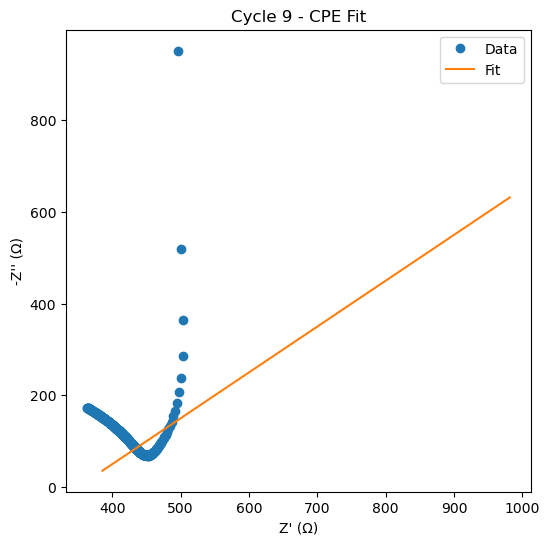


Processing cycle 10 (points 3601-3981)

Analyzing cycle 10


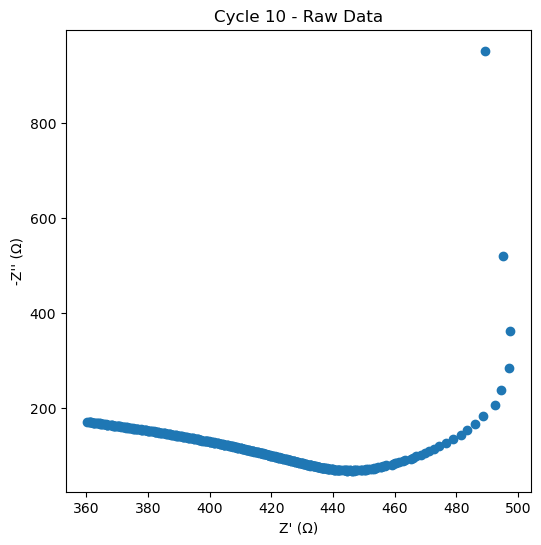

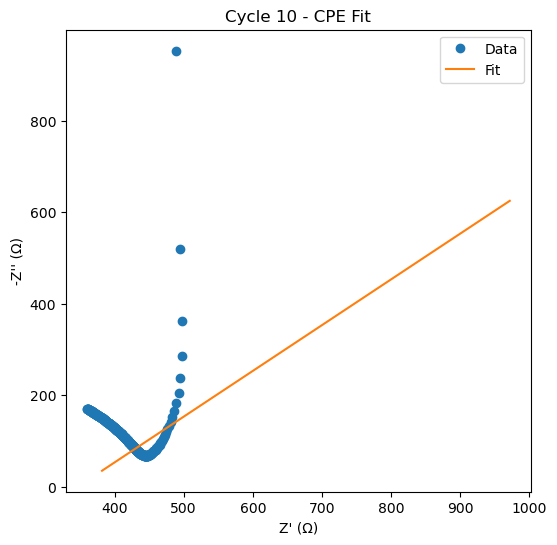


Summary of all cycles:

Cycle 1 (CPE model):
=== Modeled Parameters (CPE) ===
ΔRₑ (Solution Resistance):
  Experimental = 391.87 Ω
  Modeled (R0) = 0.00 Ω

ΔRₑₜ (Charge Transfer Resistance):
  Experimental ≈ 185.46 Ω
  Modeled (Rp) = 550.64 Ω

CPE Parameters:
  Q = 1.001e-08 S·s^n (pseudo-capacitance)
  n = 0.83 (0=resistor, 1=capacitor)

Quality Checks:
  ΔRₑ difference: 391.87 Ω
  ΔRₑₜ difference: 196.9%

----------------------------------

Cycle 2 (CPE model):
=== Modeled Parameters (CPE) ===
ΔRₑ (Solution Resistance):
  Experimental = 388.35 Ω
  Modeled (R0) = 382.19 Ω

ΔRₑₜ (Charge Transfer Resistance):
  Experimental ≈ 173.09 Ω
  Modeled (Rp) = 146180077.43 Ω

CPE Parameters:
  Q = 1.646e-05 S·s^n (pseudo-capacitance)
  n = 0.50 (0=resistor, 1=capacitor)

Quality Checks:
  ΔRₑ difference: 6.17 Ω
  ΔRₑₜ difference: 84453119.4%

----------------------------------

Cycle 3 (CPE model):
=== Modeled Parameters (CPE) ===
ΔRₑ (Solution Resistance):
  Experimental = 384.57 Ω
  Modeled (

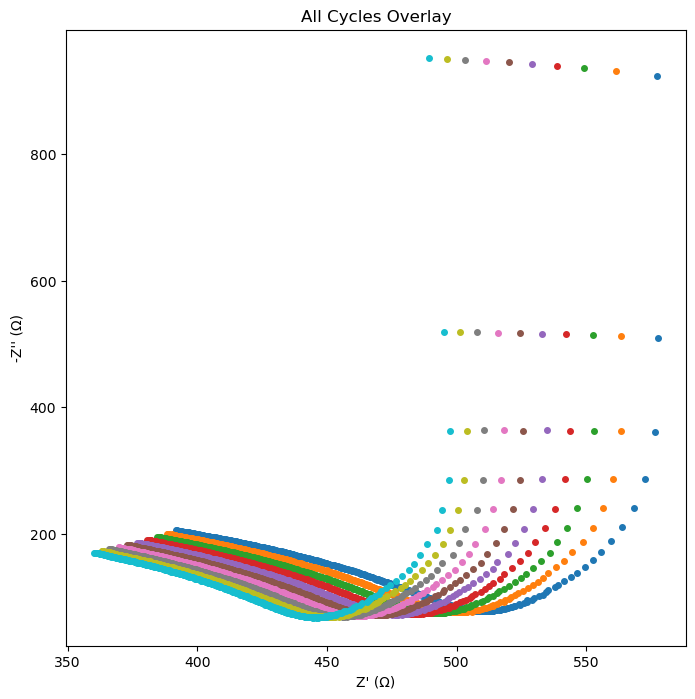

'\n    # Print summary\n    print("\nSummary of all cycles:")\n    for i, result in enumerate(eis_results):\n        print(f"\nCycle {i + 1}:")\n        print(f"Rs = {result[\'Rs\']:.2f} Ω")\n        print(f"Rp = {result[\'Rp\']:.2f} Ω")\n        print(f"Q = {result[\'Q\']:.3e} S·s^n")\n        print(f"n = {result[\'n\']:.2f}")\n'

In [ ]:
import numpy as np
import pandas as pd
from impedance.models.circuits import CustomCircuit
from impedance.visualization import plot_nyquist
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def split_cycles_from_frequency(frequency, start_val=100, end_val=200000, tol_start=20, tol_end=10000):
    """
    Splits the frequency array into cycles using relaxed tolerances.
    A cycle starts near `start_val` and ends near `end_val`.
    Removes the first data point from each complete cycle.
    """
    print(f"[Cycle Split] Looking for cycles: start ~{start_val}±{tol_start}, end ~{end_val}±{tol_end}")
    print(f"[Cycle Split] First 10 frequencies: {frequency[:10]}")

    cycles = []
    in_cycle = False
    start_idx = None
    for i, freq in enumerate(frequency):
        if not in_cycle:
            if abs(freq - start_val) <= tol_start:
                in_cycle = True
                start_idx = i + 1  # Skip first point by starting at i+1
        else:
            if abs(freq - end_val) <= tol_end:
                cycles.append((start_idx, i + 1))
                in_cycle = False
                start_idx = None
    
    # Handle last incomplete cycle (don't modify its start if incomplete)
    if in_cycle:
        cycles.append((start_idx if start_idx is not None else i, len(frequency)))
    
    print(f"[Cycle Split] Found {len(cycles)} cycles (first point removed from each complete cycle)")
    return cycles

def complex_to_z(frequencies, Z):
    """Convert complex impedance to (Z_real, Z_imag) pairs"""
    return np.vstack([Z.real, Z.imag]).T

def randles_cpe_model(f, R0, R1, Q, n):
    """Custom implementation of Randles circuit with CPE"""
    w = 2 * np.pi * f
    Z_CPE = 1/(Q * (1j * w)**n)
    Z_R1_CPE = 1/(1/R1 + 1/Z_CPE)
    return R0 + Z_R1_CPE

def randles_simple_model(f, R0, R1, C):
    """Simpler Randles circuit without CPE"""
    w = 2 * np.pi * f
    return R0 + R1/(1 + 1j * w * R1 * C)

def analyze_eis_cycle(frequencies, Z, cycle_num):
    """Analyze a single EIS cycle with robust fitting"""
    print(f"\nAnalyzing cycle {cycle_num + 1}")
    
    # Clean data
    valid_idx = (~np.isnan(Z.real)) & (~np.isnan(Z.imag)) & (frequencies > 0)
    f_clean = frequencies[valid_idx]
    Z_clean = Z[valid_idx]
    
    # Sort by frequency (high to low)
    sorted_idx = np.argsort(f_clean)[::-1]
    f_clean = f_clean[sorted_idx]
    Z_clean = Z_clean[sorted_idx]
    
    # Plot raw data
    plt.figure(figsize=(6, 6))
    plt.plot(Z_clean.real, -Z_clean.imag, 'o')
    plt.xlabel('Z\' (Ω)')
    plt.ylabel('-Z\'\' (Ω)')
    plt.title(f'Cycle {cycle_num + 1} - Raw Data')
    plt.show()
    
    # Prepare for fitting
    Z_stack = complex_to_z(f_clean, Z_clean)
    bounds = ([0, 0, 1e-8, 0.5], [np.inf, np.inf, 1, 1])  # R0, R1, Q, n
    
    try:
        # Fit CPE model
        popt, pcov = curve_fit(
            lambda f, R0, R1, Q, n: complex_to_z(f, randles_cpe_model(f, R0, R1, Q, n)).flatten(),
            f_clean, Z_stack.flatten(),
            p0=[np.median(Z_clean.real)/2, np.median(Z_clean.real)*2, 1e-5, 0.8],
            bounds=bounds,
            maxfev=10000
        )
        
        # Generate fit results
        Z_fit = randles_cpe_model(f_clean, *popt)
        
        # Plot results
        plt.figure(figsize=(6, 6))
        plt.plot(Z_clean.real, -Z_clean.imag, 'o', label='Data')
        plt.plot(Z_fit.real, -Z_fit.imag, '-', label='Fit')
        plt.xlabel('Z\' (Ω)')
        plt.ylabel('-Z\'\' (Ω)')
        plt.title(f'Cycle {cycle_num + 1} - CPE Fit')
        plt.legend()
        plt.show()
        
        return {
            'model': 'CPE',
            'parameters': popt,
            'Rs': popt[0],
            'Rp': popt[1],
            'Q': popt[2],
            'n': popt[3],
            'frequencies': f_clean,
            'Z': Z_clean,
            'Z_fit': Z_fit
        }
        
    except Exception as e:
        print(f"CPE fit failed: {str(e)}")
        print("Attempting simple RC model...")
        
        try:
            # Try simple RC model
            popt, pcov = curve_fit(
                lambda f, R0, R1, C: complex_to_z(f, randles_simple_model(f, R0, R1, C)).flatten(),
                f_clean, Z_stack.flatten(),
                p0=[np.median(Z_clean.real)/2, np.median(Z_clean.real)*2, 1e-5],
                bounds=([0, 0, 1e-8], [np.inf, np.inf, 1]),
                maxfev=10000
            )
            
            Z_fit = randles_simple_model(f_clean, *popt)
            
            plt.figure(figsize=(6, 6))
            plt.plot(Z_clean.real, -Z_clean.imag, 'o', label='Data')
            plt.plot(Z_fit.real, -Z_fit.imag, '-', label='Fit')
            plt.xlabel('Z\' (Ω)')
            plt.ylabel('-Z\'\' (Ω)')
            plt.title(f'Cycle {cycle_num + 1} - Simple RC Fit')
            plt.legend()
            plt.show()
            
            return {
                'model': 'RC',
                'parameters': popt,
                'Rs': popt[0],
                'Rp': popt[1],
                'C': popt[2],
                'frequencies': f_clean,
                'Z': Z_clean,
                'Z_fit': Z_fit
            }
            
        except Exception as simple_e:
            print(f"Simple RC fit also failed: {str(simple_e)}")
            return None

def process_eis_data(df):
    """Process complete EIS dataset"""
    # Extract data
    frequencies = df["Frequency(Hz)"].values.astype(float)
    Z_real = df["Rs"].values.astype(float)
    Z_imag = -np.abs(df["X"].values.astype(float))
    Z = Z_real + 1j * Z_imag
    
    # Split into cycles
    cycles = split_cycles_from_frequency(frequencies)
    
    # Analyze each cycle
    results = []
    for i, (start, end) in enumerate(cycles):
        print(f"\nProcessing cycle {i+1} (points {start}-{end})")
        cycle_freq = frequencies[start:end]
        cycle_Z = Z[start:end]
        result = analyze_eis_cycle(cycle_freq, cycle_Z, i)
        if result:
            results.append(result)
    
    # Print summary
    print("\nSummary of all cycles:")
    for i, result in enumerate(results):
        print(f"\nCycle {i + 1} ({result['model']} model):")
        
        # Experimental measurements from raw data
        delta_Re_exp = result['Z'].real[0]  # First point's real impedance
        delta_Rct_exp = result['Z'].real[-1] - result['Z'].real[0]  # Approximate diameter
        
        if result['model'] == 'CPE':
            print("=== Modeled Parameters (CPE) ===")
            print(f"ΔRₑ (Solution Resistance):")
            print(f"  Experimental = {delta_Re_exp:.2f} Ω")
            print(f"  Modeled (R0) = {result['Rs']:.2f} Ω")
            
            print(f"\nΔRₑₜ (Charge Transfer Resistance):")
            print(f"  Experimental ≈ {delta_Rct_exp:.2f} Ω")
            print(f"  Modeled (Rp) = {result['Rp']:.2f} Ω")
            
            print(f"\nCPE Parameters:")
            print(f"  Q = {result['Q']:.3e} S·s^n (pseudo-capacitance)")
            print(f"  n = {result['n']:.2f} (0=resistor, 1=capacitor)")
            
            # Quality check
            Re_diff = abs(result['Rs'] - delta_Re_exp)
            Rct_diff_pct = abs(result['Rp'] - delta_Rct_exp)/delta_Rct_exp*100
            print(f"\nQuality Checks:")
            print(f"  ΔRₑ difference: {Re_diff:.2f} Ω")
            print(f"  ΔRₑₜ difference: {Rct_diff_pct:.1f}%")
            
        elif result['model'] == 'RC':
            print("=== Modeled Parameters (Simple RC) ===")
            print(f"ΔRₑ (Solution Resistance):")
            print(f"  Experimental = {delta_Re_exp:.2f} Ω")
            print(f"  Modeled (R0) = {result['Rs']:.2f} Ω")
            
            print(f"\nΔRₑₜ (Charge Transfer Resistance):")
            print(f"  Experimental ≈ {delta_Rct_exp:.2f} Ω")
            print(f"  Modeled (Rp) = {result['Rp']:.2f} Ω")
            
            print(f"\nC = {result['C']:.3e} F (Double Layer Capacitance)")
            
        else:
            print("=== Experimental Measurements Only ===")
            print(f"ΔRₑ = {delta_Re_exp:.2f} Ω")
            print(f"ΔRₑₜ ≈ {delta_Rct_exp:.2f} Ω")
            print("(No valid model fit achieved)")
        
        print("\n----------------------------------")
    
    return results

# Load your data
df = pd.read_excel("100224_Chip26_Cas complex reaction steps.xlsx", sheet_name="0 Cas complex_Association")

# Process all cycles
eis_results = process_eis_data(df)

# Example usage
if __name__ == "__main__":
    # Load your data (replace with your actual loading code)
    df = pd.read_excel("100224_Chip26_Cas complex reaction steps.xlsx", sheet_name="0 Cas complex_Association")
    
    # Process all cycles
    eis_results = process_eis_data(df)
    
    # Plot all cycles together
    plt.figure(figsize=(8,8))
    for result in eis_results:
        plt.plot(result['Z'].real, -result['Z'].imag, 'o', markersize=4)
    plt.xlabel('Z\' (Ω)')
    plt.ylabel('-Z\'\' (Ω)')
    plt.title('All Cycles Overlay')
    plt.show()

    # Print summary
    print("\nSummary of all cycles:")
    for i, result in enumerate(eis_results):
        print(f"\nCycle {i + 1}:")
        print(f"Rs = {result['Rs']:.2f} Ω")
        print(f"Rp = {result['Rp']:.2f} Ω")
        print(f"Q = {result['Q']:.3e} S·s^n")
        print(f"n = {result['n']:.2f}")
'''